# TP4 AA1 - Regresión lineal

**Nicolás Druetta - DNI: 36604286.**

<br>

---

## Indicaciones básicas

1) Debe usar este notebook como template para su entrega. Haga una copia y comience a completar las consignas.

2) Cada uno debe completar las consignas indicadas en este notebook.

3) No pueden repetir el mismo dataset que ya haya definido un compañero.

4) Copias explícitas de secciones enteras del trabajo de otro será penalizado disminuyendo su puntuación.

5) No se olvide de añadir las fuentes de inspiración de su código (blogs, prompts de chatgpt o similar).

6) Además de todo el código que agregue, es importante que sepa interpretarlo. Agregue texto explicativo en cada sección. Esto le ayudará al momento del coloquio/parcial.

7) Revise las fecha límite de entrega de este trabajo.

<br>

---

## Entrega

* En el foro destinado a la tarea debe postear al menos tres veces:
  - La primera vez para indicar el dataset elegido.
  - Una segunda vez para postear su entrega.
  - Una tercera vez para brindar feedback a alguien más en el foro.
  - Puede comentar más de un posteo de sus compañeros siempre y cuando el intercambio sea respetuoso y fructífero.
* Deben postear como solución un enlace a su notebook colab público y también un enlace al mismo notebook alojado en su repositorio GitHub.
* Debe sumar el enlace a un video donde muestre su solución y explique lo realizado. Duración máxima: 5 - 10 minutos. Puede grabarse a Ud. mismo usando una sesión de zoom y grabar localmente. Puede subir el video a su youtube personal como privado o Unlisted.
* Enlaces no accesibles o enlaces erróneos es igual a determinar que la tarea no ha sido entregada. Corrobore la viabilidad de los enlaces que postea.

<br>

---

## Tarea:
### Aplicación de Regresión Lineal y Análisis de Importancia de Variables
**Objetivo**: Aplicar un modelo de regresión lineal a un dataset de su elección, evaluar su rendimiento e identificar las variables más relevantes para la predicción.

<br>

---

## Instrucciones:

### 0.&nbsp;**Importación de librerías y configuración**

In [1]:
# Importo las librerías necesarias.
import matplotlib.pyplot as plt
import pandas as pd
import requests
import urllib3
import warnings
import zipfile
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import HTML
from io import BytesIO

# Configuro la visualización de números decimales.
pd.options.display.float_format = "{:.2f}".format

# Oculto advertencias SSL generadas por verify=False.
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore", category=urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Creo una función para mostrar títulos de resultados.
def print_title(text, br_top=False):
    if br_top:
        display(HTML("<br />"))
    display(HTML(f"""
        <h3 style='font-family: Trebuchet MS, Arial, sans-serif; color: #333; margin: 0;'>
            {text}.
        </h3>
        <hr style='border: 1px solid #333; margin: 5px 45px 5px 0;' />
    """))

# Creo una función para mostrar acciones o procesos.
def print_action(text):
    display(HTML("<br />"))
    display(HTML(f"""
        <div style='border: 1px solid #333; padding: 5px; margin-right: 45px;'>
            <h3 style='font-family: Trebuchet MS, Arial, sans-serif; color: #333; margin: 0;'>
                >>> {text}.
            </h3>
        </div>
    """))
    display(HTML("<br />"))

# Creo una función para mostrar texto en negrita en los gráficos.
def text_bold(text):
    return r"\bf{" + text.replace("_", r"\_") + "}"

> Importo las librerías que necesito y dejo preparadas las funciones auxiliares para mostrar títulos, acciones y textos destacados en los gráficos.

### 1.&nbsp;**Selección del Dataset**
   - Elijan un dataset de UCI ML Repository del siguiente enlace: https://archive.ics.uci.edu/datasets/?Task=Regression&skip=0&take=10&sort=desc&orderBy=NumHits&search=
   - Requisitos:
     - Debe tener al menos 4 variables numéricas continuas (1 target, 3 o más features).
     - Idealmente, que las features tengan distintas escalas o unidades (no excluyente).
     - Revisar en el foro de la tarea que dicho dataset no haya sido ya elegido por otra persona.
     - Postee en el foro de la tarea el dataset que eligió. Continue al siguiente punto.

In [2]:
# Inicializo los parámetros para el análisis.
# Se me ocurrió hacerlo dinámico para evaluar otros datasets con el mismo código.
# Uso el de UCI para entregar el TP, pero estuve probando otros datasets también.

# Creo una función para cargar la configuración del dataset.
def load_dataset_config(dataset_type):
    configs = {
        "uci": {
            # Stock Market Prediction
            "dataset_url": "https://archive.ics.uci.edu/static/public/554/cnnpred+cnn+based+stock+market+prediction+using+a+diverse+set+of+variables.zip",
            "file_to_process": "Processed_S&P.csv",
            "target_column": "Close",
            "exclude_feature_columns": [
                # "EMA_10", "EMA_20", "EMA_50", "EMA_200"
            ],
            "max_feature_correlation": 0.97
        },
        "kaggle": {
            # US Stock Market Data
            "dataset_url": "https://www.kaggle.com/api/v1/datasets/download/nikhilkohli/us-stock-market-data-60-extracted-features",
            "file_to_process": "GOOGL.csv",
            "target_column": "Close_forcast",
            "exclude_feature_columns": [
                "Close(t)",
                "Day", "DayofWeek", "DayofYear", "Week",
                "Is_month_end", "Is_month_start", "Is_quarter_end", "Is_quarter_start",
                "Is_year_end", "Is_year_start", "Is_leap_year", "Year", "Month"
            ],
            "max_feature_correlation": 0.99
        }
    }

    # Excluyo columnas seleccionadas y columnas de fecha
    # que no voy a usar como predictoras.
    return configs[dataset_type]

# Cambiar acá para probar otro.
SOURCE = "uci" # uci = Entrega TP.

# Cargo la configuración del dataset elegido.
dataset_config = load_dataset_config(SOURCE)

# Defino los valores según la config del dataset.
dataset_url = dataset_config["dataset_url"]
file_to_process = dataset_config["file_to_process"]
target_column = dataset_config["target_column"]
exclude_feature_columns = dataset_config["exclude_feature_columns"]
max_feature_correlation = dataset_config["max_feature_correlation"]

# Muestro los parámetros principales del análisis.
print_title("Parámetros del análisis (4)")
print("Source:", SOURCE)
print("Archivo:", file_to_process)
print("Variable objetivo:", target_column)
print("Límite de correlación:", max_feature_correlation)

Source: uci
Archivo: Processed_S&P.csv
Variable objetivo: Close
Límite de correlación: 0.97


> Defino el dataset que voy a usar, el archivo que voy a procesar, la variable objetivo y el límite máximo de correlación permitido entre variables predictoras.

In [3]:
# Leo el ZIP directamente desde internet.
response = requests.get(dataset_url, verify=False)
response.raise_for_status()

# Abro el ZIP en memoria, sin guardarlo como archivo local.
zip_file = zipfile.ZipFile(BytesIO(response.content))

# Cargo el CSV indicado en la configuración.
data = pd.read_csv(zip_file.open(file_to_process))

# Muestro una vista previa del dataset.
print_title("Vista previa del dataset (" + file_to_process + ")")
display(data.head())

# Muestro los nombres de las columnas disponibles.
print_title("Columnas disponibles (" + str(len(data.columns)) + ")", br_top=True)
print(pd.Index(data.columns))

# Muestro la cantidad de filas y columnas del dataset.
print_title("Cantidad de filas y columnas", br_top=True)
print(data.shape)

,Date,Close,Volume,mom,mom1,mom2,mom3,ROC_5,ROC_10,ROC_15,...,NZD,silver-F,RUSSELL-F,S&P-F,CHF,Dollar index-F,Dollar index,wheat-F,XAG,XAU
0,2009-12-31,1115.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.03,0.26,-1.08,-1.00,-0.11,-0.08,-0.06,-0.48,0.30,0.39
1,2010-01-04,1132.99,0.92,0.02,NaN,NaN,NaN,NaN,NaN,NaN,...,1.52,3.26,1.61,1.62,-0.57,-0.59,-0.42,3.12,3.91,2.10
2,2010-01-05,1136.52,-0.38,0.00,0.02,NaN,NaN,NaN,NaN,NaN,...,-0.07,1.96,-0.20,0.31,0.43,0.03,0.12,-0.90,1.42,-0.12
3,2010-01-06,1137.14,1.00,0.00,0.00,0.02,NaN,NaN,NaN,NaN,...,0.56,2.15,-0.02,0.07,-0.56,-0.24,-0.17,2.62,2.25,1.77
4,2010-01-07,1141.69,0.06,0.00,0.00,0.00,0.02,NaN,NaN,NaN,...,-0.72,0.94,0.50,0.40,0.58,0.58,0.54,-1.85,0.22,-0.58


Index(['Date', 'Close', 'Volume', 'mom', 'mom1', 'mom2', 'mom3', 'ROC_5',
       'ROC_10', 'ROC_15', 'ROC_20', 'EMA_10', 'EMA_20', 'EMA_50', 'EMA_200',
       'DTB4WK', 'DTB3', 'DTB6', 'DGS5', 'DGS10', 'Oil', 'Gold', 'DAAA',
       'DBAA', 'GBP', 'JPY', 'CAD', 'CNY', 'AAPL', 'AMZN', 'GE', 'JNJ', 'JPM',
       'MSFT', 'WFC', 'XOM', 'FCHI', 'FTSE', 'GDAXI', 'DJI', 'HSI', 'IXIC',
       'SSEC', 'RUT', 'NYSE', 'TE1', 'TE2', 'TE3', 'TE5', 'TE6', 'DE1', 'DE2',
       'DE4', 'DE5', 'DE6', 'CTB3M', 'CTB6M', 'CTB1Y', 'Name', 'AUD', 'Brent',
       'CAC-F', 'copper-F', 'WIT-oil', 'DAX-F', 'DJI-F', 'EUR', 'FTSE-F',
       'gold-F', 'HSI-F', 'KOSPI-F', 'NASDAQ-F', 'GAS-F', 'Nikkei-F', 'NZD',
       'silver-F', 'RUSSELL-F', 'S&P-F', 'CHF', 'Dollar index-F',
       'Dollar index', 'wheat-F', 'XAG', 'XAU'],
      dtype='object')


(1984, 84)


> Cargo el dataset y miro su estructura inicial para saber cuántas filas y columnas trae antes de preparar los datos para el modelo.

### 2.&nbsp;**Análisis exploratorio**
   - Describan las variables (media, distribución, outliers).
   - Visualizen:
     - Histogramas o boxplots para ver distribuciones.
     - Gráficos de dispersión (scatterplots) entre features y target.
   - **Pregunta clave**: ¿Qué relaciones lineales preliminares observan?

In [4]:
# Copio el dataset para no modificar el original.
df = data.copy()

# Identifico las columnas no numéricas.
non_numeric_columns = df.select_dtypes(exclude=["number"]).columns

# Muestro las columnas no numéricas que voy a excluir.
print_title("Columnas no numéricas que voy a excluir (" + str(len(non_numeric_columns)) + ")")
print(pd.Index(non_numeric_columns))

# Me quedo únicamente con las columnas numéricas.
df_numeric = df.select_dtypes(include=["number"])

# Muestro la acción realizada.
print_action("Excluyo columnas no numéricas (" + str(len(non_numeric_columns)) + ") de las columnas totales (" + str(len(df.columns)) + ")")

# Muestro las columnas numéricas disponibles.
print_title("Columnas numéricas disponibles (" + str(len(df_numeric.columns)) + ")")
print(pd.Index(df_numeric.columns))

Index(['Date', 'Name'], dtype='object')


Index(['Close', 'Volume', 'mom', 'mom1', 'mom2', 'mom3', 'ROC_5', 'ROC_10',
       'ROC_15', 'ROC_20', 'EMA_10', 'EMA_20', 'EMA_50', 'EMA_200', 'DTB4WK',
       'DTB3', 'DTB6', 'DGS5', 'DGS10', 'Oil', 'Gold', 'DAAA', 'DBAA', 'GBP',
       'JPY', 'CAD', 'CNY', 'AAPL', 'AMZN', 'GE', 'JNJ', 'JPM', 'MSFT', 'WFC',
       'XOM', 'FCHI', 'FTSE', 'GDAXI', 'DJI', 'HSI', 'IXIC', 'SSEC', 'RUT',
       'NYSE', 'TE1', 'TE2', 'TE3', 'TE5', 'TE6', 'DE1', 'DE2', 'DE4', 'DE5',
       'DE6', 'CTB3M', 'CTB6M', 'CTB1Y', 'AUD', 'Brent', 'CAC-F', 'copper-F',
       'WIT-oil', 'DAX-F', 'DJI-F', 'EUR', 'FTSE-F', 'gold-F', 'HSI-F',
       'KOSPI-F', 'NASDAQ-F', 'GAS-F', 'Nikkei-F', 'NZD', 'silver-F',
       'RUSSELL-F', 'S&P-F', 'CHF', 'Dollar index-F', 'Dollar index',
       'wheat-F', 'XAG', 'XAU'],
      dtype='object')


> Miro primero cuáles columnas no numéricas voy a sacar. Después las excluyo y me quedo únicamente con las columnas numéricas para continuar el análisis.

In [5]:
# Muestro estadísticas descriptivas de todas las columnas numéricas.
print_title("Estadísticas descriptivas de las columnas numéricas (" + str(len(df_numeric.columns)) + ")")
display(df_numeric.describe())

,Close,Volume,mom,mom1,mom2,mom3,ROC_5,ROC_10,ROC_15,ROC_20,...,NZD,silver-F,RUSSELL-F,S&P-F,CHF,Dollar index-F,Dollar index,wheat-F,XAG,XAU
count,1984.00,1983.00,1983.00,1982.00,1981.00,1980.00,1979.00,1974.00,1969.00,1964.00,...,1984.00,1984.00,1984.00,1984.00,1984.00,1984.00,1984.00,1982.00,1984.00,1984.00
mean,1731.98,0.02,0.00,0.00,0.00,0.00,0.23,0.45,0.68,0.91,...,-0.00,-0.05,0.06,0.04,-0.00,0.01,0.01,-0.01,0.01,0.01
std,428.03,0.21,0.01,0.01,0.01,0.01,1.97,2.57,3.09,3.47,...,0.75,1.94,1.25,0.94,0.74,0.48,0.50,1.94,1.83,1.03
min,1022.58,-0.76,-0.07,-0.07,-0.07,-0.07,-13.01,-16.30,-15.47,-16.47,...,-4.12,-17.75,-7.54,-7.22,-15.76,-2.39,-4.28,-11.06,-12.93,-8.49
25%,1325.68,-0.09,-0.00,-0.00,-0.00,-0.00,-0.66,-0.84,-0.84,-0.88,...,-0.45,-0.95,-0.57,-0.34,-0.34,-0.27,-0.27,-1.19,-0.84,-0.52
50%,1791.08,-0.00,0.00,0.00,0.00,0.00,0.36,0.63,0.96,1.31,...,-0.01,-0.03,0.12,0.06,0.00,0.01,0.00,-0.08,0.03,0.02
75%,2081.27,0.09,0.00,0.00,0.00,0.00,1.33,2.01,2.55,3.08,...,0.47,0.93,0.74,0.50,0.35,0.28,0.28,1.07,0.92,0.57
max,2594.38,3.23,0.05,0.05,0.05,0.05,8.70,9.25,14.10,14.02,...,3.43,12.81,7.39,5.44,9.68,2.18,3.98,12.31,6.53,4.80


> Reviso las estadísticas descriptivas para mirar mínimos, máximos, medias, desvíos y posibles rangos muy distintos entre las columnas numéricas.

In [6]:
# Identifico la variable objetivo que voy a excluir como predictora.
target_feature_columns = [
    column for column in df_numeric.columns
    if column == target_column
]

# Identifico las columnas configuradas que voy a excluir como predictoras.
configured_excluded_feature_columns = [
    column for column in df_numeric.columns
    if column in exclude_feature_columns
]

# Junto la variable objetivo y las columnas configuradas que voy a excluir como predictoras.
excluded_feature_columns = target_feature_columns + configured_excluded_feature_columns

# Muestro la variable objetivo que voy a excluir como predictora.
print_title("Variable objetivo que voy a excluir como predictora (" + str(len(target_feature_columns)) + ")")
print(pd.Index(target_feature_columns))

# Muestro las columnas configuradas que voy a excluir como predictoras.
print_title("Columnas configuradas que voy a excluir como predictoras (" + str(len(configured_excluded_feature_columns)) + ")", br_top=True)
print(pd.Index(configured_excluded_feature_columns))

# Excluyo la variable objetivo y las columnas configuradas de las variables numéricas.
print_action("Excluyo la variable objetivo (" + str(len(target_feature_columns)) + ") y las columnas configuradas como no predictoras (" + str(len(configured_excluded_feature_columns)) + ") de las variables numéricas (" + str(len(df_numeric.columns)) + ")")

candidate_feature_columns = [
    column for column in df_numeric.columns
    if column not in excluded_feature_columns
]

# Muestro las variables predictoras candidatas.
print_title("Variables predictoras candidatas para evaluar (" + str(len(candidate_feature_columns)) + ")")
print(pd.Index(candidate_feature_columns))

Index(['Close'], dtype='object')


Index([], dtype='object')


Index(['Volume', 'mom', 'mom1', 'mom2', 'mom3', 'ROC_5', 'ROC_10', 'ROC_15',
       'ROC_20', 'EMA_10', 'EMA_20', 'EMA_50', 'EMA_200', 'DTB4WK', 'DTB3',
       'DTB6', 'DGS5', 'DGS10', 'Oil', 'Gold', 'DAAA', 'DBAA', 'GBP', 'JPY',
       'CAD', 'CNY', 'AAPL', 'AMZN', 'GE', 'JNJ', 'JPM', 'MSFT', 'WFC', 'XOM',
       'FCHI', 'FTSE', 'GDAXI', 'DJI', 'HSI', 'IXIC', 'SSEC', 'RUT', 'NYSE',
       'TE1', 'TE2', 'TE3', 'TE5', 'TE6', 'DE1', 'DE2', 'DE4', 'DE5', 'DE6',
       'CTB3M', 'CTB6M', 'CTB1Y', 'AUD', 'Brent', 'CAC-F', 'copper-F',
       'WIT-oil', 'DAX-F', 'DJI-F', 'EUR', 'FTSE-F', 'gold-F', 'HSI-F',
       'KOSPI-F', 'NASDAQ-F', 'GAS-F', 'Nikkei-F', 'NZD', 'silver-F',
       'RUSSELL-F', 'S&P-F', 'CHF', 'Dollar index-F', 'Dollar index',
       'wheat-F', 'XAG', 'XAU'],
      dtype='object')


> Identifico la variable objetivo y la excluyo de las posibles predictoras. También quito las columnas que decidí excluir manualmente por parámetro, y con el resto armo las variables candidatas para evaluar.

In [7]:
# Copio las variables candidatas iniciales para no modificar la lista original.
candidate_feature_columns_initial = candidate_feature_columns.copy()

# Calculo las correlaciones absolutas de las variables candidatas iniciales con la variable objetivo.
target_correlations = df_numeric[candidate_feature_columns_initial].corrwith(df_numeric[target_column]).dropna().abs().sort_values(ascending=False)

# Identifico las variables demasiado correlacionadas con la variable objetivo.
high_target_correlation_columns = list(target_correlations[target_correlations > max_feature_correlation].index)

# Muestro la acción realizada.
print_action("Detecto variables demasiado correlacionadas con el target (" + str(len(high_target_correlation_columns)) + ")")

# Creo una tabla con las variables que voy a excluir por correlación alta.
high_target_correlation_columns_df = pd.DataFrame({
    "Variable Nro": range(1, len(high_target_correlation_columns) + 1),
    "Variable": high_target_correlation_columns,
    "Correlación con la variable objetivo": [
        "{0:.2f} con {1}".format(target_correlations[column], target_column)
        for column in high_target_correlation_columns
    ]
})

# Muestro las variables que voy a excluir por correlación alta.
print_title("Variables a excluir por correlación alta con la variable objetivo (" + str(len(high_target_correlation_columns)) + ")")

with pd.option_context("display.max_rows", 10):
    display(high_target_correlation_columns_df)

,Variable Nro,Variable,Correlación con la variable objetivo
0,1,EMA_10,1.00 con Close
1,2,EMA_20,1.00 con Close
2,3,EMA_50,1.00 con Close
3,4,EMA_200,0.99 con Close


> **EMA** significa media móvil exponencial.
>
> Es un promedio del precio de cierre calculado sobre una cantidad determinada de períodos. A diferencia de un promedio común, le da más importancia a los precios más recientes, por eso sirve para ver mejor la tendencia actual del precio.
>
> Y por eso las excluyo como variables predictoras.

In [8]:
# Creo una nueva lista sin modificar las variables candidatas iniciales.
candidate_feature_columns_without_high_target_correlation = [
    column for column in candidate_feature_columns_initial
    if column not in high_target_correlation_columns
]

# Muestro la acción realizada.
print_action(
    "Excluyo variables demasiado correlacionadas con el target:<br />"
    + str(len(candidate_feature_columns_initial))
    + " candidatas - "
    + str(len(high_target_correlation_columns))
    + " excluidas = "
    + str(len(candidate_feature_columns_without_high_target_correlation))
    + " candidatas finales"
)

# Calculo y ordeno las correlaciones absolutas finales con la variable objetivo.
sorted_correlations = df_numeric[candidate_feature_columns_without_high_target_correlation].corrwith(df_numeric[target_column]).dropna().abs().sort_values(ascending=False)

# Guardo las variables candidatas finales ordenadas por correlación con la variable objetivo.
sorted_candidate_feature_columns = list(sorted_correlations.index)

# Creo una tabla con las variables candidatas finales ordenadas.
sorted_candidate_feature_columns_df = pd.DataFrame({
    "Variable Nro": range(1, len(sorted_candidate_feature_columns) + 1),
    "Variable": sorted_candidate_feature_columns,
    "Correlación con la variable objetivo": [
        "{0:.2f} con {1}".format(sorted_correlations[column], target_column)
        for column in sorted_candidate_feature_columns
    ]
})

# Muestro las variables candidatas finales ordenadas por correlación con la variable objetivo.
print_title("Variables predictoras candidatas finales ordenadas por correlación (" + str(len(sorted_candidate_feature_columns)) + ")")

with pd.option_context("display.max_rows", 10):
    display(sorted_candidate_feature_columns_df)

,Variable Nro,Variable,Correlación con la variable objetivo
0,1,DE4,0.71 con Close
1,2,DE5,0.69 con Close
2,3,DE6,0.68 con Close
3,4,DTB6,0.63 con Close
4,5,DTB3,0.60 con Close
...,...,...,...
72,73,AAPL,0.00 con Close
73,74,WFC,0.00 con Close
74,75,CAD,0.00 con Close
75,76,Dollar index-F,0.00 con Close


> Reviso automáticamente si alguna variable candidata está demasiado correlacionada con la variable objetivo. Si supera el límite definido, la dejo afuera para evitar que el modelo dependa de columnas casi iguales a la respuesta.<br>
> Después trabajo con una nueva lista de candidatas finales, sin modificar la lista original.

In [9]:
# Defino una función para seleccionar variables evitando alta correlación entre ellas.
def select_feature_columns(max_features):
    selected_feature_columns = []

    for column in sorted_candidate_feature_columns:
        if not selected_feature_columns:
            selected_feature_columns.append(column)

        else:
            feature_correlation = df_numeric[selected_feature_columns].corrwith(df_numeric[column]).abs().max()

            if feature_correlation < max_feature_correlation:
                selected_feature_columns.append(column)

        if len(selected_feature_columns) == max_features:
            break

    return selected_feature_columns

# Copio las variables candidatas finales ordenadas para no modificar la lista original.
sorted_candidate_feature_columns_for_selection = sorted_candidate_feature_columns.copy()

# Creo listas para guardar el detalle de evaluación y las variables seleccionadas.
evaluated_feature_columns = []
all_selected_feature_columns = []

# Evalúo variables para quitar correlación alta entre predictoras.
print_action("Analizo correlaciones entre variables predictoras candidatas finales (" + str(len(sorted_candidate_feature_columns_for_selection)) + ")")

# Recorro las variables candidatas finales ordenadas por correlación con la variable objetivo.
for column in sorted_candidate_feature_columns_for_selection:

    # Selecciono automáticamente la primera variable porque todavía no hay variables previas para comparar.
    if not all_selected_feature_columns:
        all_selected_feature_columns.append(column)

        evaluated_feature_columns.append([
            column,
            "{0:.2f} con {1}".format(sorted_correlations[column], target_column),
            "-",
            "Sí",
            len(all_selected_feature_columns)
        ])

    else:
        # Calculo la correlación de la variable actual con las variables ya seleccionadas.
        feature_correlations = df_numeric[all_selected_feature_columns].corrwith(df_numeric[column]).abs()

        # Identifico la variable seleccionada más parecida a la variable actual.
        max_feature = feature_correlations.idxmax()
        max_correlation = feature_correlations.max()

        # Evalúo si la variable actual supera el filtro de correlación máxima entre predictoras.
        is_selected = max_correlation < max_feature_correlation

        if is_selected:
            all_selected_feature_columns.append(column)
            feature_number = len(all_selected_feature_columns)

        else:
            feature_number = "-"

        evaluated_feature_columns.append([
            column,
            "{0:.2f} con {1}".format(sorted_correlations[column], target_column),
            "{0:.2f} con {1}".format(max_correlation, max_feature),
            "Sí" if is_selected else "No",
            feature_number
        ])

# Creo una tabla con las variables evaluadas.
evaluated_feature_columns_df = pd.DataFrame(
    evaluated_feature_columns,
    columns=[
        "Variable",
        "Correlación con la variable objetivo",
        "Mayor correlación con variables seleccionadas",
        "Seleccionada",
        "Variable Nro"
    ]
)

# Muestro las variables evaluadas.
print_title("Variables evaluadas para quitar correlación alta entre predictoras (" + str(len(evaluated_feature_columns_df)) + ")")
display(evaluated_feature_columns_df)

,Variable,Correlación con la variable objetivo,Mayor correlación con variables seleccionadas,Seleccionada,Variable Nro
0,DE4,0.71 con Close,-,Sí,1
1,DE5,0.69 con Close,1.00 con DE4,No,-
2,DE6,0.68 con Close,1.00 con DE4,No,-
3,DTB6,0.63 con Close,0.60 con DE4,Sí,2
4,DTB3,0.60 con Close,0.99 con DTB6,No,-
...,...,...,...,...,...
72,AAPL,0.00 con Close,0.67 con NASDAQ-F,Sí,62
73,WFC,0.00 con Close,0.80 con JPM,Sí,63
74,CAD,0.00 con Close,0.43 con GBP,Sí,64
75,Dollar index-F,0.00 con Close,0.91 con EUR,Sí,65


> Evalúo cada variable predictora candidata contra las variables que ya fui conservando. Si una variable es demasiado parecida a otra ya seleccionada, no la incorporo para reducir redundancia entre predictoras.

> #### Glosario:
>
> - **DTB**: tasas de Letras del Tesoro de Estados Unidos.
> - **DBAA**: rendimiento de bonos corporativos con calificación BAA.
> - **DE**: diferencias entre tasas, principalmente entre tasas corporativas y tasas del Tesoro.

In [10]:
# Identifico las variables que voy a quitar por correlación alta entre predictoras.
high_correlation_removed_feature_columns = [
    column for column in sorted_candidate_feature_columns_for_selection
    if column not in all_selected_feature_columns
]

# Muestro las variables que voy a quitar por correlación alta entre predictoras.
print_title("Variables que voy a quitar por correlación alta entre sí (" + str(len(high_correlation_removed_feature_columns)) + ")")
print(pd.Index(high_correlation_removed_feature_columns))

print_action(
    "Quito variables predictoras con correlación alta entre sí ("
    + str(len(high_correlation_removed_feature_columns))
    + ") de las variables candidatas finales ("
    + str(len(sorted_candidate_feature_columns_for_selection))
    + ")"
)

# Muestro las variables restantes después de quitar correlación alta entre predictoras.
print_title("Variables restantes para evaluar modelos (" + str(len(all_selected_feature_columns)) + ")")
print(pd.Index(all_selected_feature_columns))

Index(['DE5', 'DE6', 'DTB3', 'DTB4WK', 'TE2', 'TE1', 'CAC-F', 'GDAXI', 'mom',
       'S&P-F', 'RUT'],
      dtype='object')


Index(['DE4', 'DTB6', 'DBAA', 'TE3', 'TE6', 'DAAA', 'DE2', 'DE1', 'TE5',
       'DGS10', 'DGS5', 'ROC_20', 'ROC_15', 'ROC_10', 'MSFT', 'SSEC', 'GE',
       'ROC_5', 'HSI', 'Oil', 'JPM', 'Nikkei-F', 'HSI-F', 'GBP', 'Volume',
       'FCHI', 'JNJ', 'AMZN', 'CNY', 'IXIC', 'XAU', 'NASDAQ-F', 'DJI', 'XAG',
       'DJI-F', 'DAX-F', 'NZD', 'KOSPI-F', 'GAS-F', 'CTB6M', 'AUD', 'mom2',
       'mom1', 'XOM', 'mom3', 'wheat-F', 'FTSE', 'gold-F', 'NYSE', 'CTB1Y',
       'JPY', 'CHF', 'EUR', 'RUSSELL-F', 'FTSE-F', 'silver-F', 'CTB3M',
       'copper-F', 'Gold', 'WIT-oil', 'Brent', 'AAPL', 'WFC', 'CAD',
       'Dollar index-F', 'Dollar index'],
      dtype='object')


> Primero miro qué variables voy a quitar por correlación alta. Después las quito y me quedo con las variables restantes para evaluar modelos con distintas cantidades de variables.

In [11]:
# Creo listas para guardar los resultados.
feature_counts = []
r2_scores = []
mse_scores = []
mae_scores = []

# Evalúo modelos con distinta cantidad de variables predictoras.
print_action("Pruebo modelos desde 1 hasta " + str(len(all_selected_feature_columns)) + " variables predictoras")

# Recorro todas las cantidades posibles de variables seleccionadas.
for feature_count in range(1, len(all_selected_feature_columns) + 1):
    selected_feature_columns_to_test = select_feature_columns(feature_count)

    # Creo el dataset del modelo y elimino filas incompletas.
    model_data_to_test = df_numeric[[target_column] + selected_feature_columns_to_test].dropna()

    # Separo variables predictoras y variable objetivo.
    x_to_test = model_data_to_test[selected_feature_columns_to_test]
    y_to_test = model_data_to_test[target_column]

    # Divido los datos en entrenamiento y testeo.
    x_train_to_test, x_test_to_test, y_train_to_test, y_test_to_test = train_test_split(
        x_to_test,
        y_to_test,
        test_size=0.20,
        shuffle=False
    )

    # Entreno el modelo.
    linear_model_to_test = LinearRegression()
    linear_model_to_test.fit(x_train_to_test, y_train_to_test)

    # Genero predicciones.
    y_test_pred_to_test = linear_model_to_test.predict(x_test_to_test)

    # Guardo los resultados.
    feature_counts.append(feature_count)
    r2_scores.append(r2_score(y_test_to_test, y_test_pred_to_test))
    mse_scores.append(mean_squared_error(y_test_to_test, y_test_pred_to_test))
    mae_scores.append(mean_absolute_error(y_test_to_test, y_test_pred_to_test))

# Creo una tabla con los resultados.
feature_count_results = pd.DataFrame({
    "Cantidad de variables": feature_counts,
    "R² testeo": r2_scores,
    "MSE testeo": mse_scores,
    "MAE testeo": mae_scores
})

# Identifico el modelo con menor MAE.
best_index = feature_count_results["MAE testeo"].idxmin()
best_feature_count = int(feature_count_results.loc[best_index, "Cantidad de variables"])
best_r2 = feature_count_results.loc[best_index, "R² testeo"]
best_mse = feature_count_results.loc[best_index, "MSE testeo"]
best_mae = feature_count_results.loc[best_index, "MAE testeo"]

# Muestro la tabla con los resultados.
print_title("Resultados de testeo por cantidad de variables (" + str(len(feature_count_results)) + ")")
display(feature_count_results)

# Muestro el mejor modelo encontrado.
print_title("Mejor modelo encontrado según MAE más bajo", br_top=True)
print("Cantidad de variables:", best_feature_count)
print("R² testeo:", round(best_r2, 2))
print("MSE testeo:", round(best_mse, 2))
print("MAE testeo:", round(best_mae, 2))

,Cantidad de variables,R² testeo,MSE testeo,MAE testeo
0,1,-4.70,139481.43,362.13
1,2,0.04,23562.87,112.26
2,3,0.04,23562.87,112.26
3,4,-0.94,47458.62,157.90
4,5,-9.86,265874.83,435.46
...,...,...,...,...
61,62,-0.12,25341.31,122.76
62,63,-0.11,25251.67,122.72
63,64,-0.11,25623.73,124.48
64,65,-0.10,25233.40,123.61


Cantidad de variables: 3
R² testeo: 0.04
MSE testeo: 23562.87
MAE testeo: 112.26


> Pruebo distintas versiones del modelo, empezando con una variable predictora y agregando una más en cada vuelta. Para comparar los resultados uso R², MSE y MAE, y elijo como mejor opción la que obtiene el MAE más bajo.

In [12]:
# Defino qué valores voy a mostrar en el eje x para que se lean mejor.
x_tick_values = [value for value in feature_counts if value % 5 == 0]

if feature_counts[0] not in x_tick_values:
    x_tick_values.insert(0, feature_counts[0])

if feature_counts[-1] not in x_tick_values:
    x_tick_values.append(feature_counts[-1])

# Creo el gráfico interactivo con dos ejes.
fig = make_subplots(specs=[[{"secondary_y": True}]])

# Agrego la línea de MAE de testeo.
fig.add_trace(go.Scatter(
    x=feature_counts,
    y=mae_scores,
    mode="lines+markers",
    name="MAE testeo",
    line=dict(color="red"),
    marker=dict(color="red"),
    customdata=list(zip(r2_scores, mse_scores)),
    hovertemplate=(
        "Cantidad de variables: %{x}<br>"
        "R² testeo: %{customdata[0]:.2f}<br>"
        "MSE testeo: %{customdata[1]:.2f}<br>"
        "MAE testeo: %{y:.2f}"
        "<extra></extra>"
    )
), secondary_y=False)

# Agrego la línea de R² de testeo.
fig.add_trace(go.Scatter(
    x=feature_counts,
    y=r2_scores,
    mode="lines+markers",
    name="R² testeo",
    line=dict(color="blue"),
    marker=dict(color="blue"),
    customdata=list(zip(mse_scores, mae_scores)),
    hovertemplate=(
        "Cantidad de variables: %{x}<br>"
        "R² testeo: %{y:.2f}<br>"
        "MSE testeo: %{customdata[0]:.2f}<br>"
        "MAE testeo: %{customdata[1]:.2f}"
        "<extra></extra>"
    )
), secondary_y=True)

# Marco el mejor modelo con una línea vertical.
fig.add_vline(
    x=best_feature_count,
    line_width=3,
    line_color="green"
)

# Agrego el mejor MAE a la referencia.
fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode="lines",
    name="Mejor MAE",
    line=dict(color="green", width=3)
), secondary_y=False)

# Configuro el diseño del gráfico.
fig.update_layout(
    title=dict(
        text="Rendimiento de testeo según cantidad de variables",
        x=0.5
    ),
    xaxis_title="Cantidad de variables seleccionadas",
    xaxis=dict(
        tickmode="array",
        tickvals=x_tick_values,
        ticktext=[str(value) for value in x_tick_values]
    ),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.03,
        xanchor="center",
        x=0.5
    ),
    hovermode="x unified",
    autosize=True,
    height=500,
    margin=dict(
        t=110
    )
)

# Configuro los títulos de los ejes.
fig.update_yaxes(title_text="MAE testeo", secondary_y=False)
fig.update_yaxes(title_text="R² testeo", secondary_y=True)

# Muestro el gráfico interactivo.
print_title("Comparación interactiva del rendimiento por cantidad de variables (" + str(len(feature_counts)) + ")")
fig.show(config={"responsive": True})

# Muestro el mejor modelo encontrado.
print_title("Mejor modelo encontrado según MAE más bajo", br_top=True)
print("Cantidad de variables:", best_feature_count)
print("R² testeo:", round(best_r2, 2))
print("MSE testeo:", round(best_mse, 2))
print("MAE testeo:", round(best_mae, 2))

Cantidad de variables: 3
R² testeo: 0.04
MSE testeo: 23562.87
MAE testeo: 112.26


> Grafico el rendimiento de los modelos evaluados y marco con una línea vertical la cantidad de variables que logró el MAE más bajo. Así veo visualmente por qué me quedo con esa cantidad de variables.

In [13]:
# Guardo las variables predictoras correspondientes al mejor modelo.
selected_feature_columns = all_selected_feature_columns[:best_feature_count]

# Guardo una copia con el nombre que uso en el resto del notebook.
feature_columns = selected_feature_columns.copy()

# Muestro la acción realizada.
print_action("Me quedo con las variables que integran el mejor modelo (" + str(len(selected_feature_columns)) + ")")

# Creo una tabla con las variables predictoras del mejor modelo.
selected_feature_columns_df = pd.DataFrame({
    "Variable Nro": range(1, len(selected_feature_columns) + 1),
    "Variable": selected_feature_columns,
    "Correlación con la variable objetivo": [
        "{0:.2f} con {1}".format(sorted_correlations[column], target_column)
        for column in selected_feature_columns
    ],
    "Fuerza de correlación": [
        "muy fuerte" if abs(sorted_correlations[column]) >= 0.90 else
        "fuerte" if abs(sorted_correlations[column]) >= 0.70 else
        "moderada" if abs(sorted_correlations[column]) >= 0.50 else
        "débil"
        for column in selected_feature_columns
    ]
})

# Muestro las variables predictoras del mejor modelo.
print_title("Variables predictoras del mejor modelo (" + str(len(selected_feature_columns)) + ")")
display(selected_feature_columns_df)

,Variable Nro,Variable,Correlación con la variable objetivo,Fuerza de correlación
0,1,DE4,0.71 con Close,fuerte
1,2,DTB6,0.63 con Close,moderada
2,3,DBAA,0.58 con Close,moderada


> Selecciono las variables predictoras del mejor modelo y las dejo guardadas para usarlas en los gráficos exploratorios, el preprocesamiento y el entrenamiento final.

In [14]:
# Defino la cantidad máxima de variables predictoras que quiero graficar.
max_features_to_plot = 8

# Busco variables predictoras para graficar, empezando por las más relacionadas.
correlation_thresholds = [0.90, 0.70, 0.50, 0.30, 0.10, 0.00]
features_to_plot = []
correlation_threshold_used = None

# Defino las variables predictoras disponibles ordenadas por correlación con la variable objetivo.
available_features_to_plot = [
    column
    for column in sorted_correlations.index
    if column in feature_columns
]

# Ajusto la cantidad máxima según la cantidad de variables disponibles.
max_features_to_plot = min(max_features_to_plot, len(available_features_to_plot))

# Recorro los umbrales de correlación desde el más exigente hasta el menos exigente.
for correlation_threshold in correlation_thresholds:
    selected_features = [
        column
        for column in available_features_to_plot
        if abs(sorted_correlations[column]) >= correlation_threshold
    ]

    if len(selected_features) >= max_features_to_plot:
        features_to_plot = selected_features[:max_features_to_plot]
        correlation_threshold_used = correlation_threshold
        break

# Si no encuentro suficientes variables por umbral, completo con las variables más relacionadas disponibles.
if len(features_to_plot) < max_features_to_plot:
    features_to_plot = available_features_to_plot[:max_features_to_plot]

    if correlation_threshold_used is None:
        correlation_threshold_used = 0.00

# Defino las columnas para graficar.
columns_to_plot = [target_column] + features_to_plot

# Muestro la acción realizada.
print_action("Me quedo con la variable objetivo (" + str(len([target_column])) + ") y las mejores variables predictoras disponibles (" + str(len(features_to_plot)) + ") para los gráficos")

# Creo una tabla con las variables que voy a usar en los gráficos.
columns_to_plot_df = pd.DataFrame({
    "Variable Nro": range(1, len(columns_to_plot) + 1),
    "Variable": columns_to_plot,
    "Tipo": ["Variable objetivo"] + ["Variable predictora"] * len(features_to_plot),
    "Correlación con la variable objetivo": [
        "-"
    ] + [
        "{0:.2f} con {1}".format(sorted_correlations[column], target_column)
        for column in features_to_plot
    ],
    "Fuerza de correlación": [
        "-"
    ] + [
        "muy fuerte" if abs(sorted_correlations[column]) >= 0.90 else
        "fuerte" if abs(sorted_correlations[column]) >= 0.70 else
        "moderada" if abs(sorted_correlations[column]) >= 0.50 else
        "débil" if abs(sorted_correlations[column]) >= 0.30 else
        "muy débil"
        for column in features_to_plot
    ]
})

# Muestro las columnas que voy a usar en los gráficos.
print_title("Variables para gráficos exploratorios (" + str(len(columns_to_plot)) + ")")
display(columns_to_plot_df)

# Muestro el umbral usado para elegir las variables.
print_title("Umbral de correlación usado")
print(correlation_threshold_used)

# Calculo automáticamente la cantidad de filas y columnas para la grilla.
graph_count = len(columns_to_plot)

if graph_count % 2 == 0:
    graph_columns = 4
else:
    graph_columns = 3

graph_rows = (graph_count + graph_columns - 1) // graph_columns

# Defino figsize.
figsize = (12, graph_rows * 3)

,Variable Nro,Variable,Tipo,Correlación con la variable objetivo,Fuerza de correlación
0,1,Close,Variable objetivo,-,-
1,2,DE4,Variable predictora,0.71 con Close,fuerte
2,3,DTB6,Variable predictora,0.63 con Close,moderada
3,4,DBAA,Variable predictora,0.58 con Close,moderada


0.5


> Para los gráficos exploratorios uso la variable objetivo y las variables predictoras seleccionadas que tienen al menos una correlación moderada con ella. Así reduzco la cantidad de gráficos y me concentro en las relaciones más visibles.

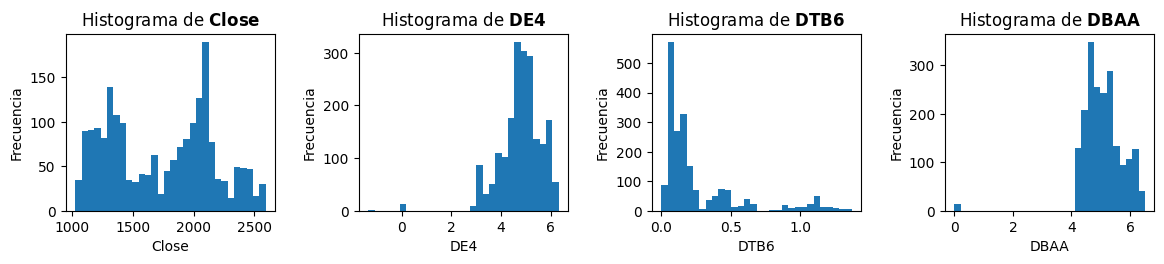

In [15]:
# Creo los gráficos de histogramas.
fig, axes = plt.subplots(graph_rows, graph_columns, figsize=figsize)
axes = axes.flatten()

# Creo un histograma para cada variable.
for index, column in enumerate(columns_to_plot):
    axes[index].hist(df_numeric[column].dropna(), bins=30)
    axes[index].set_title(f"Histograma de ${text_bold(column)}$")
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Frecuencia")

# Elimino los gráficos vacíos si sobra espacio.
for index in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[index])

# Ajusto automáticamente los espacios entre gráficos.
plt.tight_layout(pad=2.0)

# Muestro los histogramas.
print_title("Distribución de las variables seleccionadas (" + str(len(columns_to_plot)) + ")")

# Muestro la figura completa.
print()
plt.show()

> Grafico histogramas para mirar la distribución de la variable objetivo y de las variables predictoras seleccionadas. Esto me ayuda a ver concentración de valores, asimetrías y rangos antes de entrenar el modelo.

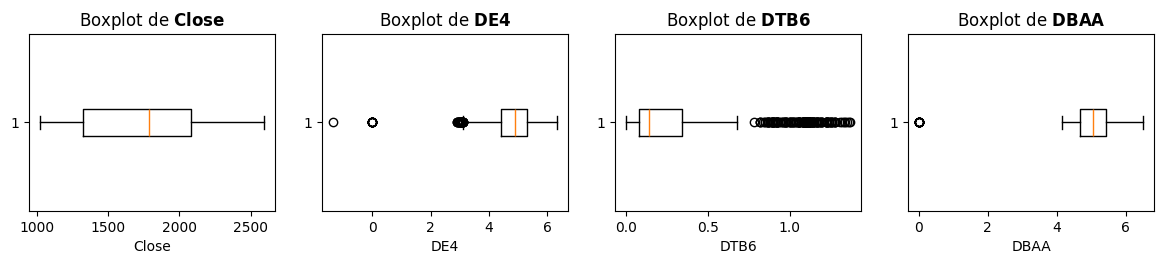

In [16]:
# Creo los gráficos de boxplots.
fig, axes = plt.subplots(graph_rows, graph_columns, figsize=figsize)
axes = axes.flatten()

# Creo un boxplot para cada variable.
for index, column in enumerate(columns_to_plot):
    axes[index].boxplot(df_numeric[column].dropna(), vert=False)
    axes[index].set_title(f"Boxplot de ${text_bold(column)}$")
    axes[index].set_xlabel(column)

# Elimino los gráficos vacíos si sobra espacio.
for index in range(len(columns_to_plot), len(axes)):
    fig.delaxes(axes[index])

# Ajusto automáticamente los espacios entre gráficos.
plt.tight_layout(pad=2.0)

# Muestro los boxplots.
print_title("Detección visual de valores atípicos (" + str(len(columns_to_plot)) + ")")

# Muestro la figura completa.
print()
plt.show()

> Grafico boxplots para detectar valores alejados del resto. Como estoy usando datos financieros, no elimino esos valores automáticamente porque pueden representar movimientos reales del mercado.

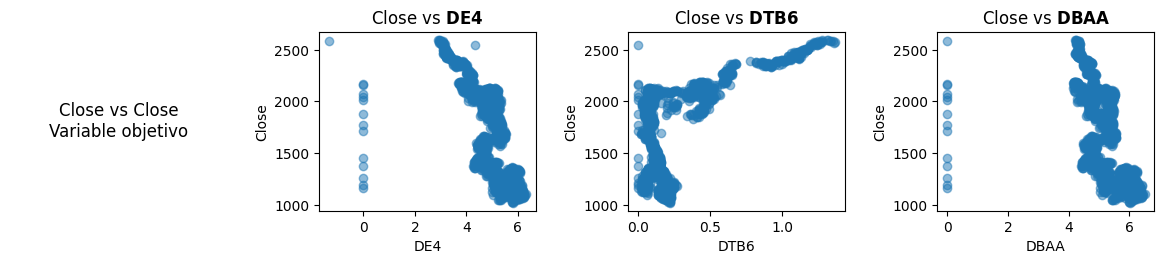

In [17]:
# Creo los gráficos de dispersión.
fig, axes = plt.subplots(graph_rows, graph_columns, figsize=figsize)
axes = axes.flatten()

# Uso la primera celda para indicar que la variable objetivo contra sí misma no se grafica.
axes[0].axis("off")
axes[0].text(
    0.5,
    0.5,
    str(target_column) + " vs " + str(target_column) + "\nVariable objetivo",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="normal"
)

# Creo un gráfico de dispersión para cada variable predictora.
axis_index = 1

for column in columns_to_plot:
    if column != target_column:
        axes[axis_index].scatter(df_numeric[column], df_numeric[target_column], alpha=0.5)
        axes[axis_index].set_title(f"{target_column} vs ${text_bold(column)}$")
        axes[axis_index].set_xlabel(column)
        axes[axis_index].set_ylabel(target_column)

        axis_index += 1

# Elimino los gráficos vacíos si sobra espacio.
for index in range(axis_index, len(axes)):
    fig.delaxes(axes[index])

# Ajusto automáticamente los espacios entre gráficos.
plt.tight_layout(pad=2.0)

# Muestro los gráficos de dispersión.
print_title("Relaciones lineales entre variables predictoras y variable objetivo (" + str(len(features_to_plot)) + ")")

# Muestro la figura completa.
print()
plt.show()

> Grafico relaciones de dispersión para revisar visualmente qué variables predictoras muestran una relación lineal más clara con la variable objetivo y cuáles presentan una relación más dispersa.

---

> ### Importante:
>
> Aunque algunas variables técnicas como **ema_10** (media móvil exponencial de 10 períodos) presentan una correlación muy alta con la variable objetivo, decidí excluirlas del modelo principal porque se calculan a partir del propio precio de cierre y pueden generar una relación demasiado directa con el target.
>
> Por eso, seleccioné variables que mantienen una correlación relevante con **Close**, pero que permiten construir un modelo más interpretable y metodológicamente más adecuado.

---

### 3.&nbsp;**Preprocesamiento**
   - Limpieza: Manejen missing values (eliminar, imputar) y outliers (si es necesario).
   - Limpieza: indique cuáles features descarta. Justifique.
   - Indique si usará o no variables categóricas. Justifique. Realice su preprocesamiento adeucado.
   - Escalen las features (p.ej., StandardScaler) para comparar coeficientes después.
   - Dividan en train/test (70-30 o 80-20).

In [18]:
# Defino las variables predictoras seleccionadas y la variable objetivo.
x = df_numeric[feature_columns].copy()
y = df_numeric[target_column].copy()

# Uno variables predictoras y variable objetivo para revisar filas incompletas.
model_data = pd.concat([x, y], axis=1)

# Guardo la cantidad de filas antes de eliminar valores faltantes.
rows_before_cleaning = len(model_data)

# Calculo los valores faltantes por columna.
missing_values = model_data.isna().sum()

# Muestro los valores faltantes antes de limpiar filas.
print_title("Valores faltantes antes de limpiar filas")
print("Columnas analizadas:", len(model_data.columns))
print("Variables predictoras:", len(feature_columns))
print("Variable objetivo:", target_column)
print() # Salto de lína.

with pd.option_context("display.max_rows", 10, "display.min_rows", 10):
    display(missing_values.to_frame("Valores faltantes"))

Columnas analizadas: 4
Variables predictoras: 3
Variable objetivo: Close



,Valores faltantes
DE4,0
DTB6,0
DBAA,0
Close,0


In [19]:
# Creo una copia del dataset del modelo sin filas con valores faltantes.
model_data_clean = model_data.dropna().copy()

# Guardo la cantidad de filas después de eliminar valores faltantes.
rows_after_cleaning = len(model_data_clean)
removed_rows = rows_before_cleaning - rows_after_cleaning

# Muestro la acción realizada.
print_action("Elimino filas con valores faltantes (" + str(removed_rows) + ")")

# Calculo los valores faltantes después de limpiar.
missing_values_after_cleaning = model_data_clean.isna().sum()

# Muestro el resumen de la limpieza.
print_title("Resumen de limpieza de filas")
print("Filas antes de la limpieza:", rows_before_cleaning)
print("Filas después de la limpieza:", rows_after_cleaning)
print("Filas eliminadas:", removed_rows)

# Muestro los valores faltantes después de limpiar filas.
print_title("Valores faltantes después de limpiar filas", br_top=True)
print("Columnas analizadas:", len(model_data_clean.columns))
print("Variables predictoras:", len(feature_columns))
print("Variable objetivo:", target_column)
print() # Salto de lína.

with pd.option_context("display.max_rows", 10, "display.min_rows", 10):
    display(missing_values_after_cleaning.to_frame("Valores faltantes"))

# Separo nuevamente variables predictoras y variable objetivo desde la copia limpia.
x = model_data_clean[feature_columns].copy()
y = model_data_clean[target_column].copy()

Filas antes de la limpieza: 1984
Filas después de la limpieza: 1984
Filas eliminadas: 0


Columnas analizadas: 4
Variables predictoras: 3
Variable objetivo: Close



,Valores faltantes
DE4,0
DTB6,0
DBAA,0
Close,0


> Reviso los valores faltantes antes de entrenar el modelo. Como la regresión lineal no puede trabajar con filas incompletas, elimino las filas que tienen algún dato faltante en las variables seleccionadas o en la variable objetivo.

In [20]:
# Creo una lista para guardar el análisis de outliers.
outlier_summary = []

# Evalúo outliers mediante el criterio IQR.
print_action("Evalúo outliers por IQR en variables predictoras (" + str(len(feature_columns)) + ")")

for column in feature_columns:
    q1 = x[column].quantile(0.25)
    q3 = x[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_quantity = ((x[column] < lower_limit) | (x[column] > upper_limit)).sum()

    outlier_summary.append({
        "Variable": column,
        "Outliers": outlier_quantity,
        "LowerLimit": lower_limit,
        "UpperLimit": upper_limit
    })

# Creo una tabla con el resumen de outliers.
outlier_summary = pd.DataFrame(outlier_summary)

# Muestro el resumen de outliers.
print_title("Resumen de outliers por variable predictora (" + str(len(outlier_summary)) + ")")

with pd.option_context("display.max_rows", 10, "display.min_rows", 10):
    display(outlier_summary)

,Variable,Outliers,LowerLimit,UpperLimit
0,DE4,43,3.12,6.61
1,DTB6,181,-0.31,0.73
2,DBAA,14,3.51,6.58


> Reviso los outliers con el criterio IQR. No los elimino automáticamente porque pueden representar valores reales del dataset.

---

> ### Importante:
>
> En datasets financieros o económicos, los outliers muchas veces son valores reales:
>  * días de crisis,
>  * cambios fuertes de mercado,
>  * movimientos bruscos de tasas,
>  * períodos anómalos,
>  * shocks económicos,
>  * volatilidad alta.
---

In [21]:
# Divido los datos en entrenamiento y prueba.
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    shuffle=False
)

# Muestro la acción realizada.
print_action("Divido los datos en entrenamiento y testeo (80/20)")

# Muestro las dimensiones finales para entrenamiento y testeo.
print_title("Dimensiones finales para entrenamiento y testeo")
print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

x_train: (1587, 3)
x_test: (397, 3)
y_train: (1587,)
y_test: (397,)


> Uso una división 80/20 porque me deja entrenar el modelo con la mayor parte del dataset y conservar una muestra suficiente para comprobar su rendimiento con datos no vistos.

### 4.&nbsp;**Regresión Lineal**
   - Ajusten un modelo de regresión lineal (usando `sklearn.linear_model.LinearRegression`).
   - Obtengan:
     - Coeficientes (pesos) del modelo.
     - Evaluar métricas en el set de entrenamiento y en el de testeo: **R²**, **MSE** (error cuadrático medio), **MAE**.

In [22]:
# Creo y entreno el modelo principal de regresión lineal con variables sin escalar.
linear_model = LinearRegression()
linear_model.fit(x_train, y_train)

# Muestro la acción realizada.
print_action("Entreno el modelo principal con variables predictoras seleccionadas (" + str(len(feature_columns)) + ")")

# Genero predicciones del modelo principal para entrenamiento y testeo.
y_train_pred = linear_model.predict(x_train)
y_test_pred = linear_model.predict(x_test)

# Creo una tabla con los coeficientes del modelo principal.
coefficients = pd.DataFrame({
    "Variable": x_train.columns,
    "Coeficiente": linear_model.coef_
}).sort_values(by="Coeficiente", key=abs, ascending=False)

# Muestro los coeficientes del modelo principal.
print_title("Coeficientes del modelo principal de regresión lineal (" + str(len(coefficients)) + ")")

with pd.option_context("display.max_rows", 10, "display.min_rows", 10):
    display(coefficients)

# Creo una tabla con las métricas de evaluación del modelo principal.
metrics = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Testeo"],
    "R²": [
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred)
    ],
    "MSE": [
        mean_squared_error(y_train, y_train_pred),
        mean_squared_error(y_test, y_test_pred)
    ],
    "MAE": [
        mean_absolute_error(y_train, y_train_pred),
        mean_absolute_error(y_test, y_test_pred)
    ]
})

# Muestro las métricas de evaluación del modelo principal.
print_title("Métricas de evaluación del modelo principal", br_top=True)
display(metrics)

,Variable,Coeficiente
1,DTB6,370.01
0,DE4,-318.32
2,DBAA,51.69


,Conjunto,R²,MSE,MAE
0,Entrenamiento,0.24,92344.51,268.26
1,Testeo,0.04,23562.87,112.26


> Entreno el modelo principal de regresión lineal con las variables sin escalar. Después comparo R², MSE y MAE en entrenamiento y testeo para ver si el modelo generaliza bien.

In [23]:
# Creo una tabla con fechas, valores reales y valores predichos por el modelo principal.
predictions_plot = pd.DataFrame({
    "Fecha": pd.to_datetime(df.loc[y_test.index, "Date"]) if "Date" in df.columns else y_test.index,
    "{0} real".format(target_column): y_test.values,
    "{0} predicho".format(target_column): y_test_pred
})

# Creo el gráfico interactivo.
fig = go.Figure()

# Agrego la serie real.
fig.add_trace(go.Scatter(
    x=predictions_plot["Fecha"],
    y=predictions_plot["{0} real".format(target_column)],
    mode="lines",
    name="{0} real".format(target_column)
))

# Agrego la serie predicha por el modelo principal.
fig.add_trace(go.Scatter(
    x=predictions_plot["Fecha"],
    y=predictions_plot["{0} predicho".format(target_column)],
    mode="lines",
    name="{0} predicho".format(target_column)
))

# Configuro el diseño del gráfico.
fig.update_layout(
    title=dict(
        text="{0} real vs {0} predicho".format(target_column),
        x=0.5
    ),
    xaxis_title="Fecha",
    yaxis_title=target_column,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.03,
        xanchor="center",
        x=0.5
    ),
    hovermode="x unified",
    autosize=True,
    height=500
)

# Muestro la acción realizada.
print_action("Grafico valores reales y predichos del modelo principal en testeo")

# Muestro el gráfico interactivo.
print_title("Comparación interactiva entre valores reales y valores predichos del modelo principal")
fig.show()

> En este gráfico reviso qué tan cerca quedan los valores predichos por el modelo principal de los valores reales. Cuanto más se acercan las líneas, mejor acompaña el modelo la tendencia de la variable objetivo.

In [24]:
# Creo un dataframe para revisar el comportamiento de las predicciones.
print_action("Analizo los casos donde el modelo tuvo mayor error")

predictions_review = x_test.copy()
predictions_review["CloseReal"] = y_test
predictions_review["ClosePredicho"] = y_test_pred
predictions_review["ErrorAbsoluto"] = abs(predictions_review["CloseReal"] - predictions_review["ClosePredicho"])

# Muestro las predicciones con mayor error absoluto.
predictions_review_top = predictions_review.sort_values("ErrorAbsoluto", ascending=False).head(10)

print_title("Revisión de predicciones con mayor error absoluto (" + str(len(predictions_review_top)) + ")")
display(predictions_review_top)

# Identifico las filas donde todas las variables predictoras valen cero.
zero_predictor_rows = predictions_review[
    (predictions_review[selected_feature_columns] == 0).all(axis=1)
]

# Muestro las filas donde todas las variables predictoras valen cero.
print_title("Filas con todas las variables predictoras en cero (" + str(len(zero_predictor_rows)) + ")", br_top=True)
display(zero_predictor_rows)

,DE4,DTB6,DBAA,CloseReal,ClosePredicho,ErrorAbsoluto
1980,-1.34,1.34,0.00,2582.30,3811.63,1229.33
1956,4.34,0.00,4.34,2544.73,1732.08,812.65
1705,0.00,0.00,0.00,2163.66,2889.26,725.60
1729,0.00,0.00,0.00,2164.45,2889.26,724.81
1778,4.14,0.60,4.74,2298.37,2038.43,259.94
1793,4.04,0.66,4.70,2349.25,2090.39,258.86
1798,3.96,0.65,4.61,2363.81,2107.51,256.30
1791,4.04,0.62,4.66,2328.25,2073.53,254.72
1794,4.00,0.65,4.65,2347.22,2096.84,250.38
1795,3.98,0.65,4.63,2351.16,2102.17,248.99


,DE4,DTB6,DBAA,CloseReal,ClosePredicho,ErrorAbsoluto
1705,0.00,0.00,0.00,2163.66,2889.26,725.60
1729,0.00,0.00,0.00,2164.45,2889.26,724.81


> Reviso las predicciones con mayor error para ver en qué casos el modelo se equivoca más. También miro si hay filas donde las tres variables valen 0, porque en esos casos el modelo tiene poca información para hacer una buena predicción.

### 5.&nbsp;**Importancia de Variables**
   - Analicen los **coeficientes** del modelo:
     - Valores absolutos altos → mayor impacto en el target.
     - Signo: Relación positiva/negativa con el target.
   - Comparen la magnitud de los coeficientes **escalados** (si usaron features en distintas unidades).
   - **5.1. Opcional**:
     Otra forma es "desordenar" un feature y ver cómo empeora el modelo. Si al desordenarlo el error aumenta mucho, ese feature era importante. Usen métodos como:
     - **Permutation Importance** (de sklearn) para validar importancia. Más info en https://scikit-learn.org/stable/modules/permutation_importance.html

In [25]:
# Creo el escalador.
scaler = StandardScaler()

# Escalo las variables predictoras de entrenamiento.
x_train_scaled = scaler.fit_transform(x_train)

# Escalo las variables predictoras de testeo usando el mismo escalador.
x_test_scaled = scaler.transform(x_test)

# Convierto los arrays escalados en DataFrames.
x_train_scaled = pd.DataFrame(x_train_scaled, columns=feature_columns, index=x_train.index)
x_test_scaled = pd.DataFrame(x_test_scaled, columns=feature_columns, index=x_test.index)

# Muestro la acción realizada.
print_action("Escalo variables predictoras con StandardScaler (" + str(len(feature_columns)) + ")")

# Muestro las variables predictoras escaladas de entrenamiento.
print_title("Variables predictoras escaladas de entrenamiento (" + str(len(feature_columns)) + ")")

with pd.option_context("display.max_rows", 10, "display.min_rows", 10):
    display(x_train_scaled)

# Muestro las variables predictoras escaladas de testeo.
print_title("Variables predictoras escaladas de testeo (" + str(len(feature_columns)) + ")", br_top=True)

with pd.option_context("display.max_rows", 10, "display.min_rows", 10):
    display(x_test_scaled)

,DE4,DTB6,DBAA
0,1.68,0.64,1.72
1,1.71,0.44,1.72
2,1.59,0.33,1.58
3,1.68,0.13,1.64
4,1.65,0.23,1.63
...,...,...,...
1582,-1.07,2.27,-0.71
1583,-1.03,2.17,-0.68
1584,-1.07,2.27,-0.71
1585,-1.01,2.17,-0.66


,DE4,DTB6,DBAA
1587,-1.04,2.37,-0.66
1588,-1.07,2.68,-0.65
1589,-1.10,2.88,-0.65
1590,-1.15,2.58,-0.74
1591,-1.13,2.47,-0.74
...,...,...,...
1979,-3.31,12.15,-1.43
1980,-9.85,12.26,-7.73
1981,-3.23,12.36,-1.33
1982,-3.29,12.56,-1.36


> Aplico **StandardScaler** porque las variables predictoras tienen rangos distintos y necesito dejarlas en una escala comparable. Uso este escalador porque centra los datos alrededor de 0 y los expresa según su desviación estándar, lo que me permite comparar mejor los coeficientes del modelo escalado.<br>
>
> Mantengo el modelo sin escalar como modelo principal para las predicciones y uso el modelo escalado solamente para interpretar la importancia relativa de las variables.

In [26]:
# Entreno el modelo escalado con las variables escaladas.
linear_model_scaled = LinearRegression()
linear_model_scaled.fit(x_train_scaled, y_train)

# Creo una tabla para interpretar la importancia de las variables con coeficientes comparables.
feature_importance = pd.DataFrame({
    "Variable": x_train_scaled.columns,
    "Coeficiente escalado": linear_model_scaled.coef_,
    "Coeficiente escalado absoluto": abs(linear_model_scaled.coef_)
})

# Agrego el sentido de la relación con la variable objetivo.
feature_importance["Efecto sobre la predicción"] = feature_importance["Coeficiente escalado"].apply(
    lambda value: "Sube la predicción" if value > 0 else "Baja la predicción"
)

# Ordeno las variables según su impacto absoluto.
feature_importance = feature_importance.sort_values(
    by="Coeficiente escalado absoluto",
    ascending=False
)

# Muestro la acción realizada.
print_action("Ordeno variables por importancia según coeficientes escalados (" + str(len(feature_importance)) + ")")

# Muestro la importancia de variables.
print_title("Importancia de variables según coeficientes escalados (" + str(len(feature_importance)) + ")")

with pd.option_context("display.max_rows", 14, "display.min_rows", 14):
    display(feature_importance)

# Identifico las variables con mayor impacto positivo y negativo.
most_positive_variable = feature_importance.sort_values(
    by="Coeficiente escalado",
    ascending=False
).iloc[0]

most_negative_variable = feature_importance.sort_values(
    by="Coeficiente escalado",
    ascending=True
).iloc[0]

most_important_variable = feature_importance.iloc[0]

# Muestro una interpretación breve.
print_title("Conclusión sobre la importancia de las variables", br_top=True)
print("La variable con mayor impacto general es:", most_important_variable["Variable"])
print("La variable que más sube la predicción es:", most_positive_variable["Variable"])
print("La variable que más baja la predicción es:", most_negative_variable["Variable"])

,Variable,Coeficiente escalado,Coeficiente escalado absoluto,Efecto sobre la predicción
0,DE4,-94.02,94.02,Baja la predicción
2,DBAA,-82.96,82.96,Baja la predicción
1,DTB6,53.42,53.42,Sube la predicción


La variable con mayor impacto general es: DE4
La variable que más sube la predicción es: DTB6
La variable que más baja la predicción es: DE4


> Entreno un segundo modelo con variables escaladas únicamente para interpretar coeficientes comparables.
>
> Miro esos coeficientes para responder:
> * Qué variables pesan más.
> * Qué variables aumentan la predicción.
> * Qué variables reducen la predicción.

### 6.&nbsp;**Reflexión**
   - ¿Cuáles variables son más importantes según el modelo? ¿Coincide con su análisis exploratorio?
   - ¿El modelo tiene buen rendimiento (R² alto, MSE bajo)? Si no, ¿a qué podría deberse?

> **Respuesta:**<br>
>
> Las variables más importantes son las predictoras seleccionadas por el modelo. Esto coincide con el análisis exploratorio, porque tenían una relación relevante con **Close**.<br>
>
> En la selección también dejé afuera variables que estaban demasiado relacionadas con la variable objetivo. Aunque podían mejorar el resultado, preferí no depender de variables casi iguales a la respuesta.<br>
>
> El modelo tiene un rendimiento aceptable, aunque no perfecto. Puede acompañar parte del comportamiento de **Close**, pero también comete errores porque estoy usando un modelo lineal simple sobre datos financieros, donde la relación entre variables puede ser más compleja.

## **Bonus**:
- Prueben eliminar variables "poco importantes" y reentrenar el modelo. ¿Mejora el rendimiento?



> **Respuesta:**<br>
>
> Gracias a la sugerencia del bonus, amplié el análisis y probé el rendimiento del modelo con distintas cantidades de variables. En lugar de elegirlas manualmente, evalué modelos desde 1 hasta todas las variables predictoras restantes y conservé la cantidad que obtuvo el menor **MAE**.<br>
>
> Además, dejé el código genérico para poder probar otros datasets.

## **Tips**:
- Si el R² es muy bajo, revisen si hay relaciones no lineales (y consideren transformar features).
- Documenten cada paso: ¡la trazabilidad es clave en ciencia de datos!  
- Al final de su trabajo debe crear un apartado de REFERENCIAS para citar todo recurso utilizado. Si usó IA, debe citarla.

> **Referencias:**
>
> - UCI Machine Learning Repository. (s. f.). *CNNPred: CNN-based Stock Market Prediction Using a Diverse Set of Variables*. https://archive.ics.uci.edu/static/public/554/cnnpred+cnn+based+stock+market+prediction+using+a+diverse+set+of+variables.zip
>
> - Material de clase y consignas del trabajo práctico.
>
> - Búsquedas en internet para aclarar conceptos puntuales durante el desarrollo.
>
> - Pruebas propias realizadas para ajustar el análisis, tomar decisiones y revisar el comportamiento del modelo.
>
> - ChatGPT. (2026). Herramienta utilizada como apoyo para resolver dudas sobre Python, organizar ideas e interpretar resultados.